In [2]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel1=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [3]:
times=data1['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
kms=np.argmax(data1['xh'].values-data1['xh'][0].values >= 1)

In [4]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [101]:
################
#PLOTTING
plotting=False #KEEP FALSE WHEN JOBARRAY IS RUNNING
plotting=True

In [102]:
if plotting==True:
    VAR1_name='qv'
    VAR2_name='th';VAR2_unit='(K)'
    VAR2_name='w';VAR2_unit='(m/s)'
    dir2=dir+'Project_Algorithms/Tracked_Profiles/'
    in_file=dir2+f"Entrainment_Trackback_{VAR1_name}+{VAR2_name}_{res}_{t_res}_{Np_str}.h5"
    
    import pickle
    with open(in_file, "rb") as f:
        Dictionary = pickle.load(f)

In [111]:
# #TESTING
# for key in Dictionary:
#     print(np.where(Dictionary[key]!=0))

In [103]:
if plotting==True:
    histz_vals=[200,500,1000] #unit: meters
    histt_vals=[0,300,600,900,1200] #unit:seconds
    [histz, histt, histt_str, histz_str, intervals] = SetupHistSampling(histz_vals, histt_vals)
    print(intervals)

[0, 300, 600, 900, 1200]


In [104]:
#PLOTTING FUNCTIONS
def histogram2d_colors():
    colors_rgb = [
        [44, 87, 169],    # Blue 1
        [54, 92, 171],    # Blue 2
        [66, 97, 175],    # Blue 3
        [67, 107, 182],   # Blue 4
        [70, 117, 187],   # Blue 5
        [70, 125, 193],   # Blue 6
        [74, 140, 204],   # Blue 7
        [76, 157, 216],   # Blue 8
        [75, 178, 232],   # Blue 9
        [78, 192, 242],   # Blue 10
        [110, 201, 242],   # Blue 11
        [140, 207, 240],   # Blue 12
        [161, 219, 245],   # Blue 13
        [190, 226, 226],   # Blue 14
    
        [40, 150, 40],    # Green 1
        [60, 160, 60],    # Green 2
        [80, 180, 80],    # Green 3
        [120, 200, 120],  # Green 4
        
        # [225, 237, 178],   # Yellow 1
        [244, 239, 125],   # Yellow 2
        [247, 232, 75],   # Yellow 3
        [249, 213, 43],   # Yellow 4
        [247, 194, 14],   # Orange 1
        [245, 178, 15],   # Orange 2
        [242, 159, 19],   # Orange 4
        [238, 141, 22],   # Orange 5
        [236, 121, 26],   # Orange 6
        
        [230, 77, 34],   # Red 1
        [229, 51, 35],   # Red 2
        [228, 37, 30],   # Red 3
        [220, 29, 32],   # Red 4
        [205, 28, 32],   # Red 5
        
    ]
    colors = [[c / 255 for c in color] for color in colors_rgb]
    
    # #TESTING
    # custom_cmap = mcolors.ListedColormap(colors)
    
    # # Create an array to display the colorbar
    # data = np.linspace(0, 1, len(colors)).reshape(1, -1)
    
    # # Plotting the colorbar
    # fig, ax = plt.subplots(figsize=(10, 2))
    # cbar = ax.imshow(data, cmap=custom_cmap, aspect='auto')
    # ax.set_axis_off() 
    return colors

In [105]:
#PLOTTING FUNCTIONS
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm

def initialize_colorbar(bin_array, num_contour_levels):
    colors = histogram2d_colors()
    custom_cmap = mcolors.ListedColormap(colors)
    custom_cmap.set_under("white")
    levels = np.linspace(np.min(bin_array), np.max(bin_array), num_contour_levels)
    norm = BoundaryNorm(levels, len(colors))
    return custom_cmap, norm, levels

# [custom_cmap, norm, levels]=initialize_colorbar(bin_array, num_contour_levels=30)

ValueError: Contour levels must be increasing

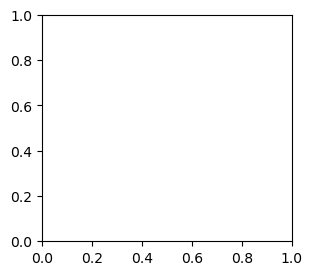

In [106]:
if plotting == True:
    def format_axes(ax, i, j, nrows, ncols, bin_array, xlabel="X-axis label", ylabel="Y-axis label"):
        if i == nrows - 1:
            num_bins=5
            ax.set_xlabel(xlabel)
            x_ticks_positions=np.linspace(bin_left1*1000,bin_right1*1000,num_bins)
            ax.set_xticks(np.linspace(0,bin_array.shape[1],num_bins));
            ax.set_xticklabels([f'{p:.1f}' for p in x_ticks_positions]);
        else:
            ax.set_xticks([])
    
        if j == 0:
            num_bins=10
            ax.set_ylabel(ylabel)
            y_ticks_positions=np.linspace(bin_left2,bin_right2,num_bins)
            ax.set_yticks(np.linspace(0,bin_array.shape[1],num_bins));
            ax.set_yticklabels([f'{p:.1f}' for p in y_ticks_positions]);
        else:
            ax.set_yticks([])


    def plot_histogram_grid(data_dict, histz_vals, histt_vals, xlabel,ylabel):
        fig = plt.figure(figsize=(20, 10))
        gs = gridspec.GridSpec(len(histz_vals), len(histt_vals), figure=fig, wspace=0.3, hspace=0.2)
    
        for i, z in enumerate(histz_vals):
            for j, (t, t_int) in enumerate(zip(histt_vals,intervals)):
                key = f'{z}_{t}'
                ax = fig.add_subplot(gs[i, j])
                
                if key in data_dict:
                    bin_array = data_dict[key]
                    [custom_cmap, norm, levels] = initialize_colorbar(bin_array, num_contour_levels=30)
                    im = ax.contourf(bin_array, levels=levels, cmap=custom_cmap, norm=norm, extend='min')
                    
                    ax.set_title(f'z={z} m, t={t_int} s', fontsize=9)
                    format_axes(ax, i, j, len(histz_vals), len(histt_vals), 
                                bin_array, xlabel=xlabel, ylabel=ylabel)
                    fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
                else:
                    ax.axis('off')
    
        fig.suptitle(f'Particle Number Distribution Binned by QV and {VAR2_name.upper()} \nWhen Tracking Entrained Parcels Back \n(ALL Tracked Parcels)', fontsize=14)
    
    histz_vals = ['200', '500', '1000']  # unit: meters
    histt_vals = ['0', '300', '600', '900', '1200']  # unit: seconds
    plot_histogram_grid(Dictionary, histz_vals, histt_vals, xlabel="qv (g/kg)",ylabel=f"{VAR2_name} {VAR2_unit}")

In [52]:
#OLD TESTING

In [ ]:
# #TESTING
# for key in Dictionary:
#     if np.where(Dictionary[key]!=0):
#         print(key)

In [533]:
# #TESTING
# def GetTZYX(ARR):
#     Ts=ARR[:,1]
#     Zs=Z[t_lst,p_lst]
#     Ys=Y[t_lst,p_lst]
#     Xs=X[t_lst,p_lst]
#     return Ts,Zs,Ys,Xs
# Ts,Zs,Ys,Xs=GetTZYX(ARR)